In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings

warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True)

In [2]:
def value_iteration_gambler(p_h=0.4, theta=1e-9, goal=100):
    
    V = np.zeros(goal + 1)
    V[goal] = 1.0  

    sweep = 0
    while True:
        delta = 0  
        
        for s in range(1, goal):
            v_old = V[s]
            
            actions = range(1, min(s, goal - s) + 1)
            
            action_values = [p_h * V[s + a] + (1 - p_h) * V[s - a] for a in actions]
            
            V[s] = max(action_values)
            
            delta = max(delta, abs(v_old - V[s]))
        
        sweep += 1
        
        if delta < theta:
            print(f"Value iteration converged in {sweep} sweeps with max delta: {delta:.2e}")
            break

    policy = {}
    for s in range(1, goal):
        actions = range(1, min(s, goal - s) + 1)
        action_values = [p_h * V[s + a] + (1 - p_h) * V[s - a] for a in actions]
        
        best_val = np.round(max(action_values), 7)
        best_actions = [a for a, val in zip(actions, action_values) if np.round(val, 7) == best_val]
        
        policy[s] = best_actions[0]
        
    return V, policy

In [3]:
p_h = 0.4
V, policy = value_iteration_gambler(p_h=p_h, theta=1e-9, goal=100)

Value iteration converged in 17 sweeps with max delta: 7.48e-10


In [4]:
print("Optimal Value Function V*(s):")
print(f"  V*(Capital = $0)   : {V[0]:.6f} (Terminal Ruin)")
print(f"  V*(Capital = $1)   : {V[1]:.6f}")
print(f"  V*(Capital = $25)  : {V[25]:.6f}")
print(f"  V*(Capital = $50)  : {V[50]:.6f}")
print(f"  V*(Capital = $75)  : {V[75]:.6f}")
print(f"  V*(Capital = $99)  : {V[99]:.6f}")
print(f"  V*(Capital = $100) : {V[100]:.6f} (Terminal Goal)")

Optimal Value Function V*(s):
  V*(Capital = $0)   : 0.000000 (Terminal Ruin)
  V*(Capital = $1)   : 0.002066
  V*(Capital = $25)  : 0.160000
  V*(Capital = $50)  : 0.400000
  V*(Capital = $75)  : 0.640000
  V*(Capital = $99)  : 0.964333
  V*(Capital = $100) : 1.000000 (Terminal Goal)


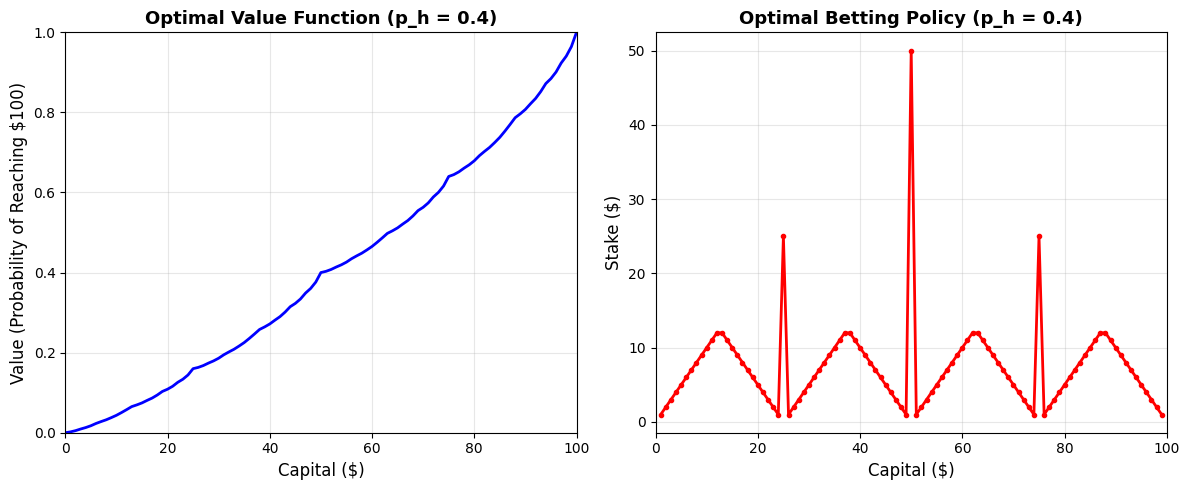

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(V)), V, linewidth=2, color='blue')
plt.xlabel('Capital ($)', fontsize=12)
plt.ylabel('Value (Probability of Reaching $100)', fontsize=12)
plt.title(f'Optimal Value Function (p_h = {p_h})', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim([0, 100])
plt.ylim([0, 1])

plt.subplot(1, 2, 2)
stakes = [policy.get(s, 0) for s in range(1, 100)]
plt.plot(range(1, 100), stakes, linewidth=2, color='red', marker='o', markersize=3)
plt.xlabel('Capital ($)', fontsize=12)
plt.ylabel('Stake ($)', fontsize=12)
plt.title(f'Optimal Betting Policy (p_h = {p_h})', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim([0, 100])

plt.tight_layout()
plt.show()

Value iteration converged in 17 sweeps with max delta: 7.48e-10
Value iteration converged in 13 sweeps with max delta: 4.73e-11
Value iteration converged in 1628 sweeps with max delta: 9.96e-10


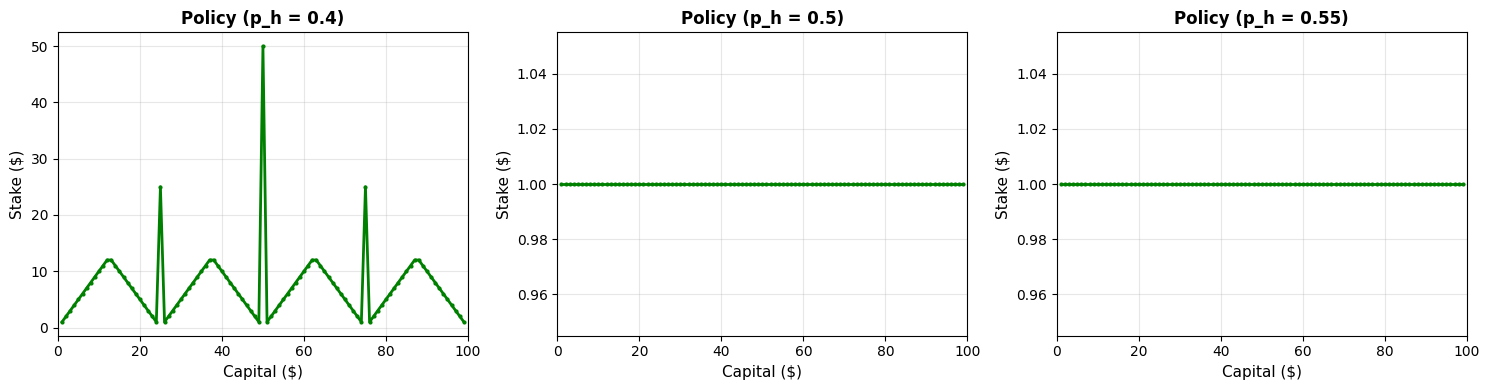

In [6]:
probabilities = [0.4, 0.5, 0.55]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, p in enumerate(probabilities):
    V_p, policy_p = value_iteration_gambler(p_h=p, theta=1e-9, goal=100)
    stakes_p = [policy_p.get(s, 0) for s in range(1, 100)]
    
    axes[idx].plot(range(1, 100), stakes_p, linewidth=2, color='green', marker='o', markersize=2)
    axes[idx].set_xlabel('Capital ($)', fontsize=11)
    axes[idx].set_ylabel('Stake ($)', fontsize=11)
    axes[idx].set_title(f'Policy (p_h = {p})', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 100])

plt.tight_layout()
plt.show()